# References
- https://github.com/MyoHub/myosuite/blob/main/docs/source/tutorials/3_Analyse_movements.ipynb

# Common Libraries

In [1]:
import os
import skvideo.io
import numpy as np
from myosuite.utils import gym
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from sklearn.decomposition import NMF

MyoSuite:> Registering Myo Envs


/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoSarcArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoFatiArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoArmReachRandom-v0 already in registry.
  logger.warn(f"Overriding environment {new_spe

# Functions

In [7]:
def VAF(W, H, A):
    """
    Args:
        W: ndarray, m x rank matrix, m-muscles x activation coefficients obtained from (# rank) nmf
        H: ndarray, rank x L matrix, basis vectors obtained from nmf where L is the length of the signal
        A: ndarray, m x L matrix, original time-invariant sEMG signal
    Returns:
        global_VAF: float, VAF calculated for the entire A based on the W&H
        local_VAF: 1D array, VAF calculated for each muscle (column) in A based on W&H
    """
    SSE_matrix = (A - np.dot(W, H))**2
    SST_matrix = (A)**2

    global_SSE = np.sum(SSE_matrix)
    global_SST = np.sum(SST_matrix)
    global_VAF = 100 * (1 - global_SSE / global_SST)

    local_SSE = np.sum(SSE_matrix, axis = 0)
    local_SST = np.sum(SST_matrix, axis = 0)
    local_VAF = 100 * (1 - np.divide(local_SSE, local_SST))

    return global_VAF, local_VAF

# Environment

In [ ]:
env = gym.make('myoElbowPose1D6MRandom-v0')

# Policy

In [6]:
pi = PPO("MlpPolicy", env, verbose=0) # Proximal Policy Optimization, Tells the AI to use a standard Multi-Layer Perceptron
pi.learn(total_timesteps=1000) # The agent tries to move the elbow, fails, gets a "reward" (or penalty), and updates its neural network weights 

/home/seojin/.local/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


# Simulation

In [3]:
env.reset()

data_store = []
for _ in range(10): # 10 episodes
    for _ in range(100): # 100 samples for each episode
        o = env.get_obs()
        a = pi.predict(o)[0] # Given this elbow position (o), what muscle command (a) should I give?
        next_o, r, done, *_, ifo = env.step(a) # Applies those muscle commands to the physics engine
                    
        data_store.append({"action":a.copy(), 
                            "jpos":env.sim.data.qpos.copy(), 
                            "mlen":env.sim.data.actuator_length.copy(), 
                            "act":env.sim.data.act.copy()})

env.close()

/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_obs to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_obs` for environment variables or `env.get_wrapper_attr('get_obs')` that will search the reminding wrappers.
  logger.warn(
/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.sim to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.sim` for environment variables or `env.get_wrapper_attr('sim')` that will search the reminding wrappers.
  logger.warn(


# Analyze

/home/seojin/.local/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/seojin/.local/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/seojin/.local/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/seojin/.local/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/seojin/.local/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


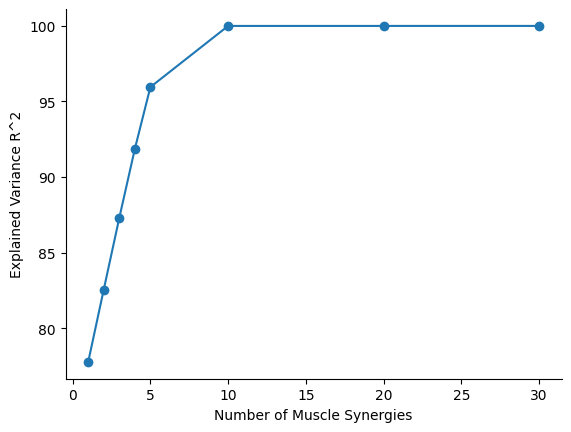

In [5]:
act = np.array([dd['act'] for dd in data_store])

VAFstore=[]
SSE, SST = [], []

sample_points = [1,2,3,4,5,10,20,30]
for isyn in sample_points:
    nmf_model = NMF(n_components=isyn, init='random', random_state=0);
    W = nmf_model.fit_transform(act)
    H = nmf_model.components_

    global_VAF, local_VAF = VAF(W, H, act)

    VAFstore.append(global_VAF)

plt.plot(sample_points,VAFstore,'-o')
plt.xlabel('Number of Muscle Synergies')
plt.ylabel('Explained Variance R^2')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)